In [1]:
import numpy as np
import pandas as pd
import scanpy as sc

In [2]:
sc.settings.verbosity = 3             # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()
sc.settings.set_figure_params(dpi=80, facecolor='white')

/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


scanpy==1.9.1 anndata==0.8.0 umap==0.5.3 numpy==1.23.5 scipy==1.10.0 pandas==1.5.3 scikit-learn==1.2.1 statsmodels==0.13.5 python-igraph==0.10.4 pynndescent==0.5.8


In [3]:
sc1 = sc.read_10x_mtx('/seq/epiprod02/etorlait/p16/Published_Data/Centenarian_10x_5p/J-DU000592/FromRiken/04.SC1/')

--> This might be very slow. Consider passing `cache=True`, which enables much faster reading from a cache file.


In [4]:
sc1

AnnData object with n_obs × n_vars = 1686 × 33694
    var: 'gene_ids', 'feature_types'

In [5]:
#find filtered cells barcodes
sc1.obs

""
AAACCTGCACCGAAAG-1
AAACCTGTCTACTTAC-1
AAACGGGTCAATCACG-1
AAACGGGTCCGCATCT-1
AAAGATGAGATATGGT-1
...
TTTGCGCGTCACCTAA-1
TTTGGTTGTACTTCTT-1
TTTGGTTGTTGTGGAG-1
TTTGTCAGTATAATGG-1


In [6]:
sc1_list=['SC1_5GEX-' + idx.replace('-1', '') for idx in sc1.obs.index]
sc1_list2=[idx.replace('-1', '') for idx in sc1.obs.index]

In [7]:
len(sc1_list)

1686

In [8]:
sc1_list2

['AAACCTGCACCGAAAG',
 'AAACCTGTCTACTTAC',
 'AAACGGGTCAATCACG',
 'AAACGGGTCCGCATCT',
 'AAAGATGAGATATGGT',
 'AAAGATGAGATCCGAG',
 'AAAGATGAGCGTTCCG',
 'AAAGATGAGTCAATAG',
 'AAAGATGGTGTGCGTC',
 'AAAGATGTCGCCAAAT',
 'AAAGCAAGTTAAGAAC',
 'AAAGTAGAGCAGACTG',
 'AAAGTAGAGGACTGGT',
 'AAAGTAGAGTGCCATT',
 'AAATGCCCACCAGGCT',
 'AAATGCCGTCAGGACA',
 'AACACGTAGTCCTCCT',
 'AACACGTAGTTCGCGC',
 'AACACGTCACAAGACG',
 'AACACGTCATACGCCG',
 'AACACGTCATACGCTA',
 'AACACGTGTCGAATCT',
 'AACACGTTCAATCACG',
 'AACACGTTCAGGCCCA',
 'AACCATGCAAATTGCC',
 'AACCATGCAATGAAAC',
 'AACCATGCACGTCTCT',
 'AACCATGGTATGCTTG',
 'AACCATGGTTAAAGTG',
 'AACCATGTCACCTTAT',
 'AACCATGTCTGATTCT',
 'AACCGCGCATGCCTTC',
 'AACCGCGGTACCGAGA',
 'AACCGCGGTGCGCTTG',
 'AACGTTGCAGCTGGCT',
 'AACGTTGCATCTCGCT',
 'AACGTTGGTTCGAATC',
 'AACGTTGTCAAACCGT',
 'AACGTTGTCTCCAACC',
 'AACTCAGTCCAGAAGG',
 'AACTCCCAGCACCGTC',
 'AACTCCCCAACCGCCA',
 'AACTCCCTCCAAATGC',
 'AACTCCCTCCGTAGTA',
 'AACTCTTGTAAAGTCA',
 'AACTCTTGTGTCGCTG',
 'AACTCTTTCATAGCAC',
 'AACTGGTTCCA

In [9]:
sc1_adata = sc.read_10x_mtx('/seq/epiprod02/etorlait/p16/Published_Data/Centenarian_10x_5p/J-DU000592/FromTerra/Mapped_STARsolo_VersionB_newSTsl/SC1_5GEX/Solo.out/Gene/raw/')

--> This might be very slow. Consider passing `cache=True`, which enables much faster reading from a cache file.


In [10]:
sc1_adata

AnnData object with n_obs × n_vars = 737280 × 60670
    var: 'gene_ids', 'feature_types'

In [11]:
sc1_adata.obs

""
AAACCTGAGAAACCAT
AAACCTGAGAAACCGC
AAACCTGAGAAACCTA
AAACCTGAGAAACGAG
AAACCTGAGAAACGCC
...
TTTGTCATCTTTACAC
TTTGTCATCTTTACGT
TTTGTCATCTTTAGGG
TTTGTCATCTTTAGTC


In [12]:
sc1_adata_f=sc1_adata[sc1_adata.obs.index.isin(sc1_list2)]

In [13]:
sc1_adata_f

View of AnnData object with n_obs × n_vars = 1686 × 60670
    var: 'gene_ids', 'feature_types'

In [14]:
sc1_adata_f.var

,gene_ids,feature_types
DDX11L1,ENSG00000223972.5,Gene Expression
WASH7P,ENSG00000227232.5,Gene Expression
MIR6859-1,ENSG00000278267.1,Gene Expression
MIR1302-2HG,ENSG00000243485.5,Gene Expression
MIR1302-2,ENSG00000284332.1,Gene Expression
...,...,...
MT-ND6,ENSG00000198695.2,Gene Expression
MT-TE,ENSG00000210194.1,Gene Expression
MT-CYB,ENSG00000198727.2,Gene Expression
MT-TT,ENSG00000210195.2,Gene Expression


In [15]:
sc1_genes=sc.get.obs_df(sc1_adata_f, keys=["CDKN2A_p14", "CDKN2A_p16", "CDKN2B", "CDKN2B-AS1"])

In [16]:
sc1_genes

,CDKN2A_p14,CDKN2A_p16,CDKN2B,CDKN2B-AS1
AAACCTGCACCGAAAG,0.0,0.0,0.0,0.0
AAACCTGTCTACTTAC,0.0,0.0,0.0,0.0
AAACGGGTCAATCACG,0.0,0.0,0.0,0.0
AAACGGGTCCGCATCT,0.0,0.0,0.0,0.0
AAAGATGAGATATGGT,0.0,0.0,0.0,0.0
...,...,...,...,...
TTTGCGCGTCACCTAA,0.0,0.0,0.0,0.0
TTTGGTTGTACTTCTT,0.0,0.0,0.0,0.0
TTTGGTTGTTGTGGAG,0.0,0.0,0.0,0.0
TTTGTCAGTATAATGG,0.0,0.0,0.0,0.0


In [17]:
sc1_genes.CDKN2A_p14.value_counts()

0.0    1585
1.0      93
2.0       6
3.0       2
Name: CDKN2A_p14, dtype: int64

In [18]:
sc1_genes.CDKN2A_p16.value_counts()

0.0    1681
1.0       3
2.0       1
3.0       1
Name: CDKN2A_p16, dtype: int64

In [19]:
sc1_genes.CDKN2B.value_counts()

0.0    1680
1.0       4
2.0       2
Name: CDKN2B, dtype: int64

In [20]:
sc1_genes['CDKN2B-AS1'].value_counts()

0.0    1679
1.0       6
2.0       1
Name: CDKN2B-AS1, dtype: int64

normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
computing PCA
    on highly variable genes
    with n_comps=50
    finished (0:00:00)


/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  cax = scatter(


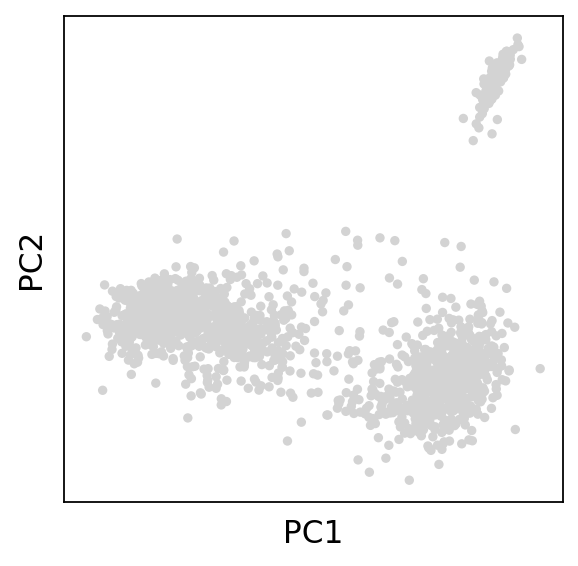

computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:01)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:04)


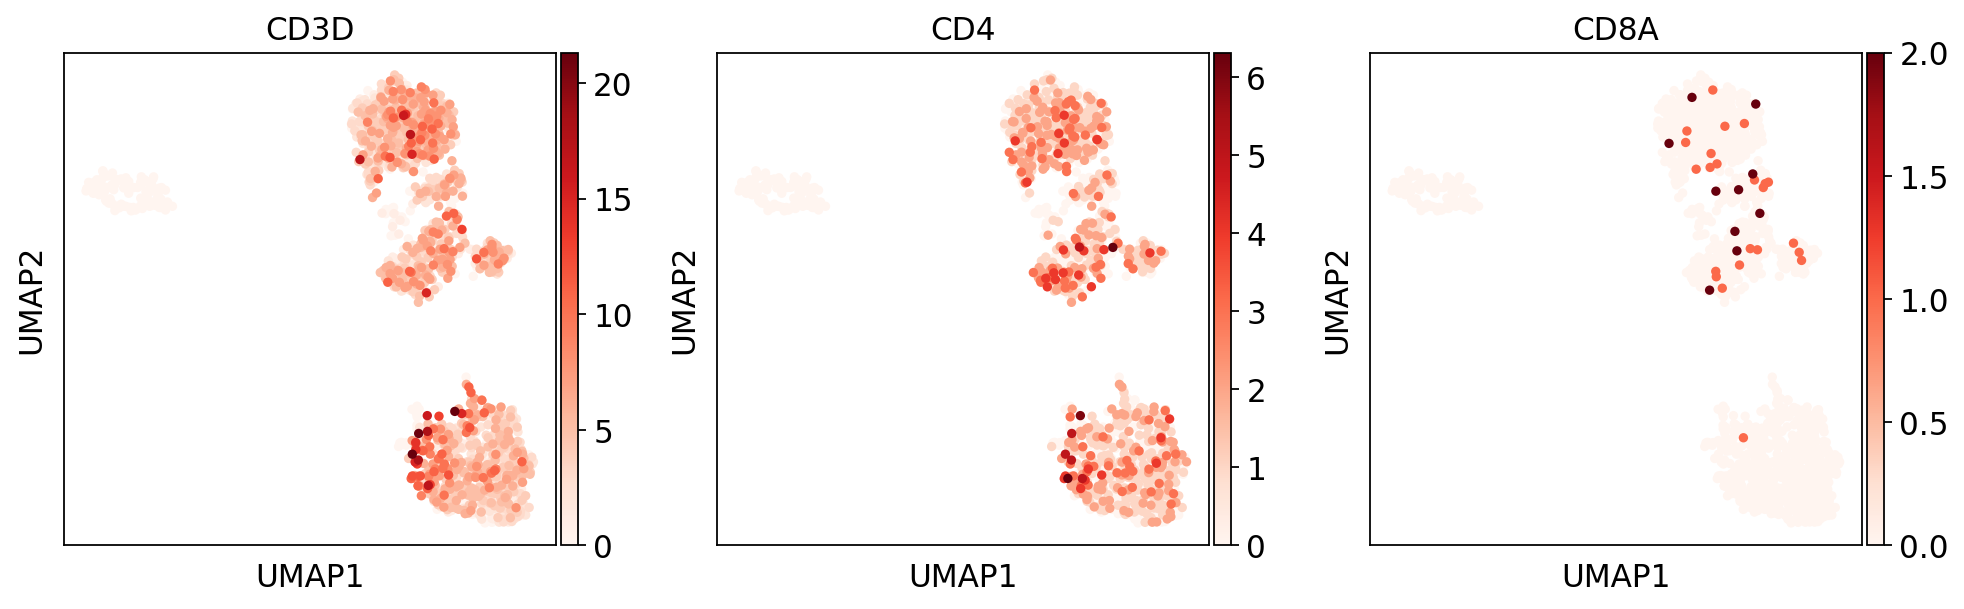

In [21]:
sc1_adata_f.raw = sc1_adata_f.copy()

sc.pp.normalize_total(sc1_adata_f, target_sum=1e4)
sc.pp.log1p(sc1_adata_f)
sc.pp.highly_variable_genes(sc1_adata_f)

sc.tl.pca(sc1_adata_f, svd_solver='arpack')
sc.pl.pca(sc1_adata_f)
sc.pp.neighbors(sc1_adata_f)
sc.tl.umap(sc1_adata_f)

sc.pl.umap(sc1_adata_f, color=['CD3D', 'CD4', 'CD8A'], color_map='Reds', vmax='p99.9')


In [22]:
sc1_adata_f.var

,gene_ids,feature_types,highly_variable,means,dispersions,dispersions_norm
DDX11L1,ENSG00000223972.5,Gene Expression,False,1.000000e-12,NaN,0.000000
WASH7P,ENSG00000227232.5,Gene Expression,False,1.313823e-02,0.574994,-0.429597
MIR6859-1,ENSG00000278267.1,Gene Expression,False,1.000000e-12,NaN,0.000000
MIR1302-2HG,ENSG00000243485.5,Gene Expression,False,1.000000e-12,NaN,0.000000
MIR1302-2,ENSG00000284332.1,Gene Expression,False,1.000000e-12,NaN,0.000000
...,...,...,...,...,...,...
MT-ND6,ENSG00000198695.2,Gene Expression,True,1.610623e+00,2.073804,0.864580
MT-TE,ENSG00000210194.1,Gene Expression,False,1.000000e-12,NaN,0.000000
MT-CYB,ENSG00000198727.2,Gene Expression,False,3.529233e+00,3.129483,2.121467
MT-TT,ENSG00000210195.2,Gene Expression,False,1.000000e-12,NaN,0.000000


In [23]:
sc1_adata_f.var[sc1_adata_f.var.index.isin(['CDKN2A_p16'])]

,gene_ids,feature_types,highly_variable,means,dispersions,dispersions_norm
CDKN2A_p16,ENSG00000147889.17_p16,Gene Expression,False,0.009047,1.409786,1.196847


In [24]:
sc1_adata_f.var[sc1_adata_f.var.index.isin(['CDKN2A_p14'])]

,gene_ids,feature_types,highly_variable,means,dispersions,dispersions_norm
CDKN2A_p14,ENSG00000147889.17_p14,Gene Expression,True,0.108613,1.232622,0.851675


In [25]:
sc1_adata_f

AnnData object with n_obs × n_vars = 1686 × 60670
    var: 'gene_ids', 'feature_types', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

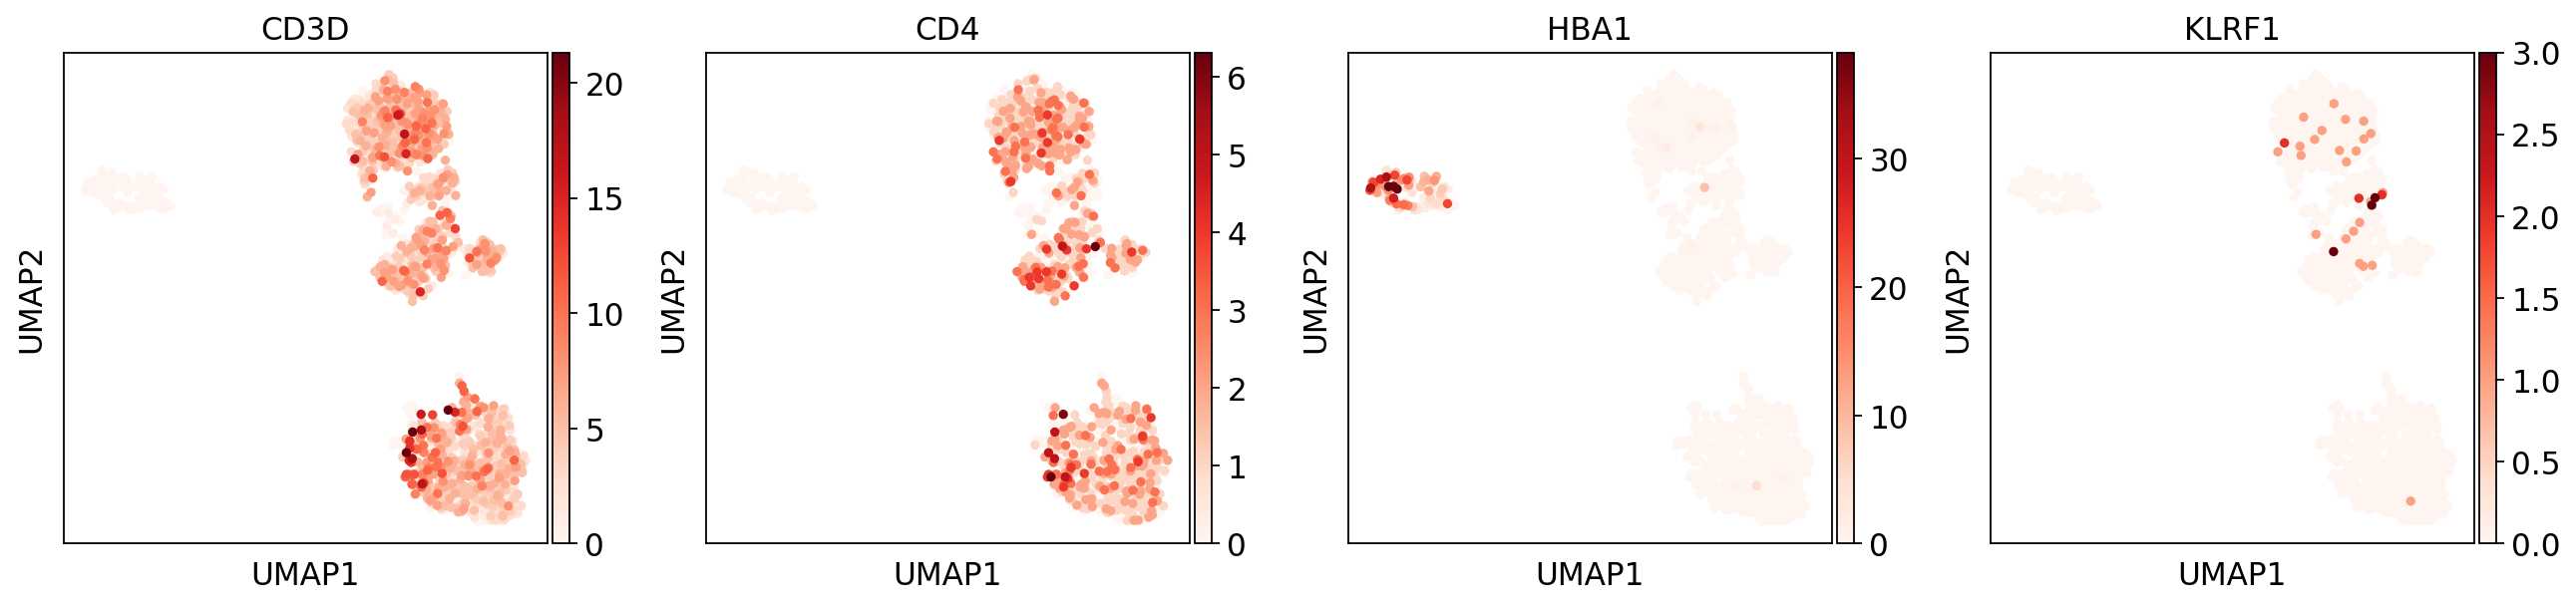

In [26]:
sc.pl.umap(sc1_adata_f, color=['CD3D', 'CD4', 'HBA1', 'KLRF1'], color_map='Reds', vmax='p99.9')


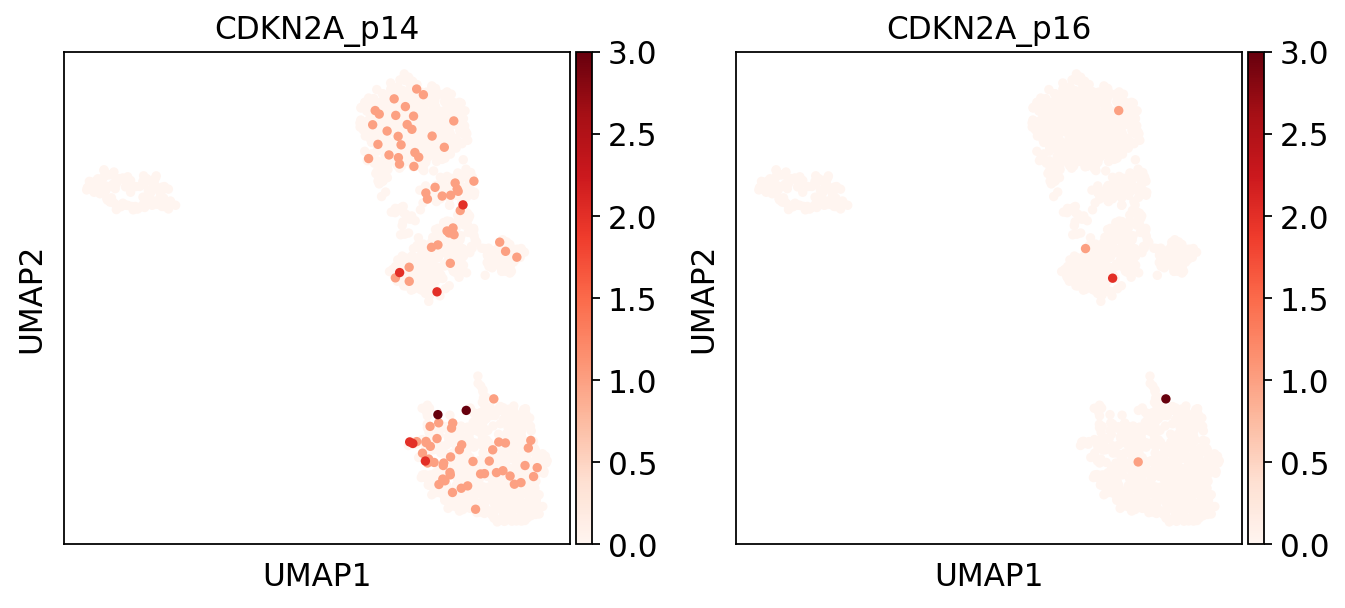

In [29]:
sc.pl.umap(sc1_adata_f, color=['CDKN2A_p14', 'CDKN2A_p16'], color_map='Reds',  use_raw=True)


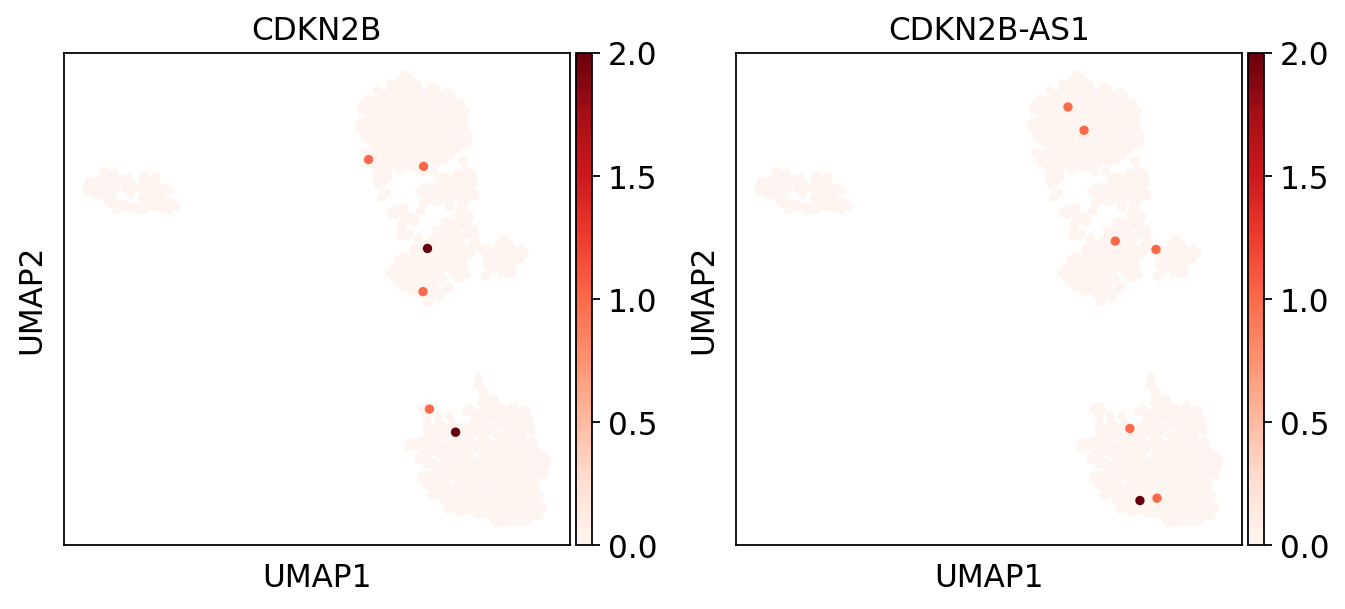

In [30]:
sc.pl.umap(sc1_adata_f, color=['CDKN2B', 'CDKN2B-AS1'], color_map='Reds', use_raw=True)



In [31]:
sc.tl.leiden(sc1_adata_f,
    resolution=0.01,
    random_state=0,
    n_iterations=2,
    directed=False,
)

running Leiden clustering
    finished: found 2 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)


/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


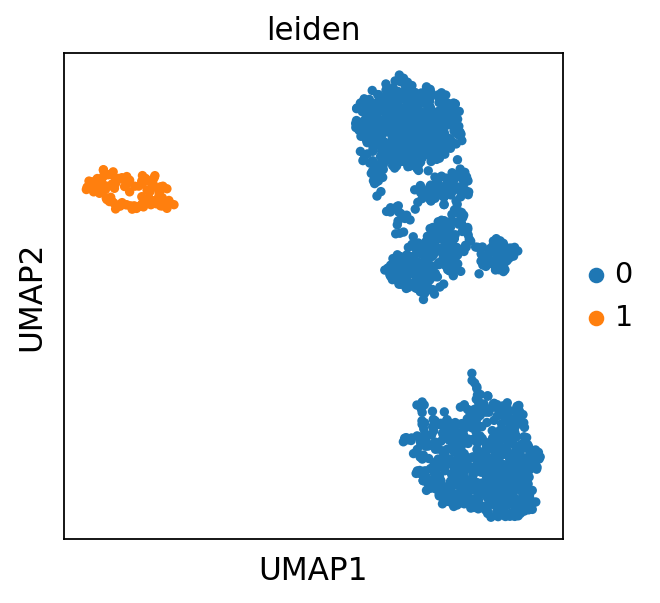

In [32]:
sc.pl.umap(sc1_adata_f, color=['leiden'], color_map='Reds', vmax='p99.9')


In [33]:
sc1_adata_f.obs

,leiden
AAACCTGCACCGAAAG,0
AAACCTGTCTACTTAC,0
AAACGGGTCAATCACG,0
AAACGGGTCCGCATCT,0
AAAGATGAGATATGGT,0
...,...
TTTGCGCGTCACCTAA,0
TTTGGTTGTACTTCTT,0
TTTGGTTGTTGTGGAG,0
TTTGTCAGTATAATGG,0


In [34]:
sc1_adata_f.obs['cellType'] = np.where(sc1_adata_f.obs['leiden'] == '0', 'T_cell', 'Ery_cell')
sc1_adata_f.obs

,leiden,cellType
AAACCTGCACCGAAAG,0,T_cell
AAACCTGTCTACTTAC,0,T_cell
AAACGGGTCAATCACG,0,T_cell
AAACGGGTCCGCATCT,0,T_cell
AAAGATGAGATATGGT,0,T_cell
...,...,...
TTTGCGCGTCACCTAA,0,T_cell
TTTGGTTGTACTTCTT,0,T_cell
TTTGGTTGTTGTGGAG,0,T_cell
TTTGTCAGTATAATGG,0,T_cell


In [35]:
sc1_adata_f.obs['cellType'].value_counts()

T_cell      1583
Ery_cell     103
Name: cellType, dtype: int64

In [36]:
sc1_data= sc.get.obs_df(sc1_adata_f,
        keys=["cellType",'CDKN2A_p14', 'CDKN2A_p16', 'CDKN2B', 'CDKN2B-AS1'], use_raw=True    )

In [37]:
sc1_data

,cellType,CDKN2A_p14,CDKN2A_p16,CDKN2B,CDKN2B-AS1
AAACCTGCACCGAAAG,T_cell,0.0,0.0,0.0,0.0
AAACCTGTCTACTTAC,T_cell,0.0,0.0,0.0,0.0
AAACGGGTCAATCACG,T_cell,0.0,0.0,0.0,0.0
AAACGGGTCCGCATCT,T_cell,0.0,0.0,0.0,0.0
AAAGATGAGATATGGT,T_cell,0.0,0.0,0.0,0.0
...,...,...,...,...,...
TTTGCGCGTCACCTAA,T_cell,0.0,0.0,0.0,0.0
TTTGGTTGTACTTCTT,T_cell,0.0,0.0,0.0,0.0
TTTGGTTGTTGTGGAG,T_cell,0.0,0.0,0.0,0.0
TTTGTCAGTATAATGG,T_cell,0.0,0.0,0.0,0.0


In [40]:
#checking that this table is having raw Counts values
sc1_data.CDKN2B.value_counts()

0.0    1680
1.0       4
2.0       2
Name: CDKN2B, dtype: int64

In [41]:
sc1_data.to_csv('/seq/epiprod02/etorlait/p16/Published_Data/Centenarian_10x_5p/J-DU000592/FromTerra/Mapped_STARsolo_VersionB_newSTsl/SC1_idsFromRiken_celltype_9p21genes.tsv', sep='\t')

/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


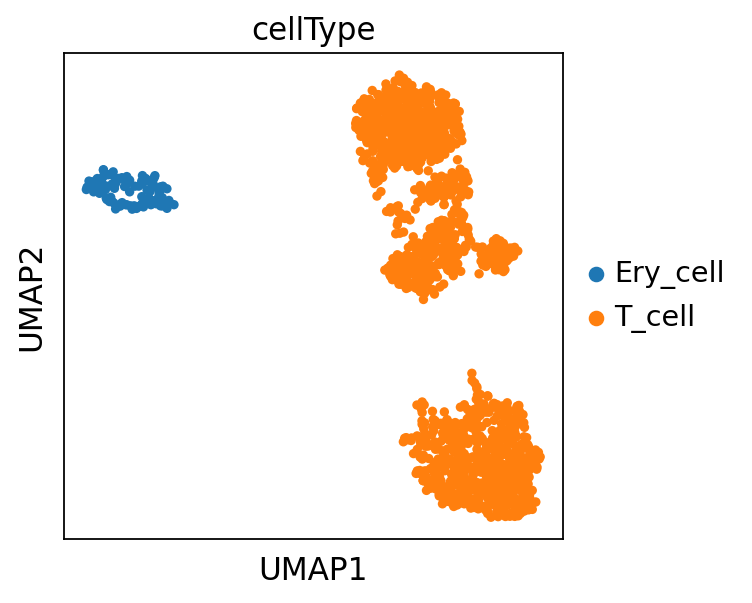

In [43]:
sc.pl.umap(sc1_adata_f, color=['cellType'])


/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


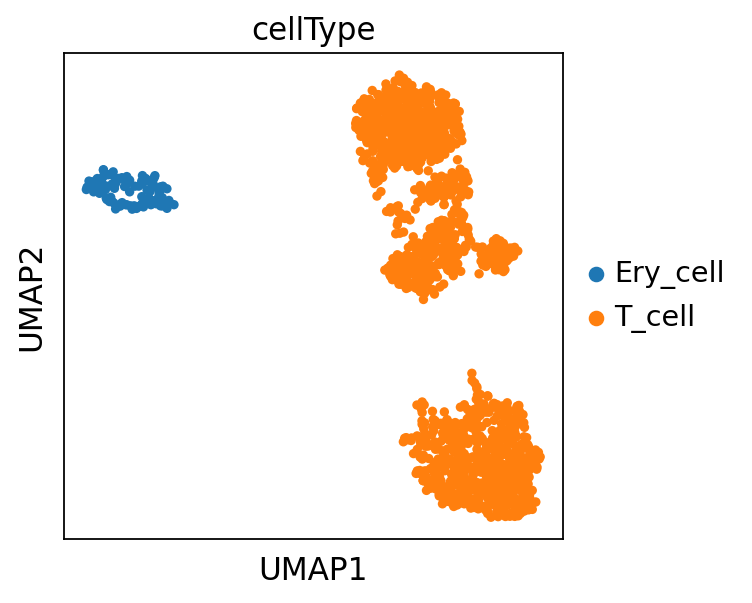

In [44]:
sc.pl.umap(sc1_adata_f, color=['cellType'], save='Hashimoto_SC1_Celltypes.pdf')


/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


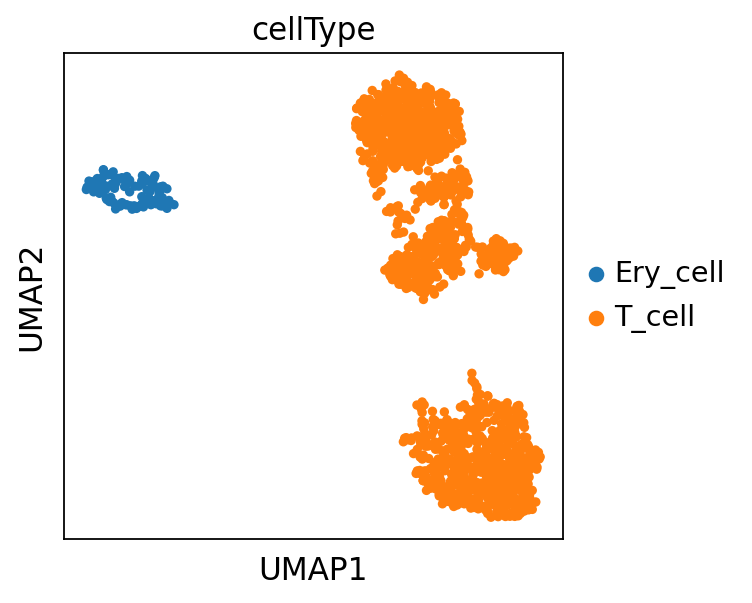

In [45]:
sc.pl.umap(sc1_adata_f, color=['cellType'], save='Hashimoto_SC1_Celltypes.pdf')


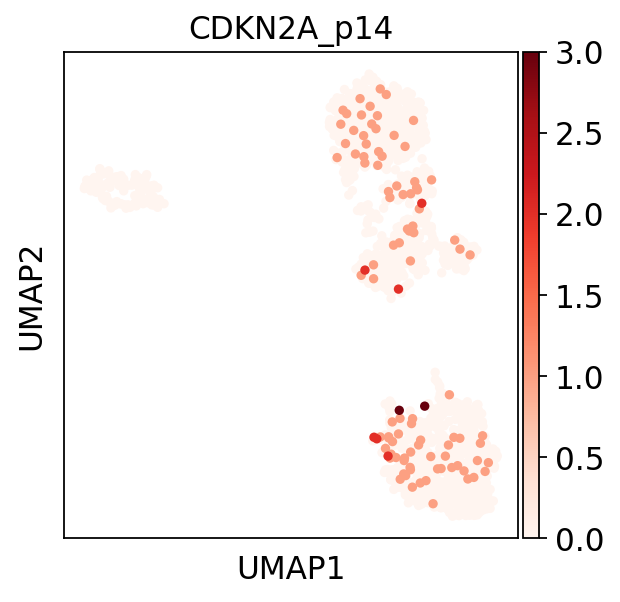

In [46]:
sc.pl.umap(sc1_adata_f, color=['CDKN2A_p14'], color_map='Reds',  use_raw=True, 
           save='Hashimoto_SC1_CDKN2A_p14_RawCounts.pdf')


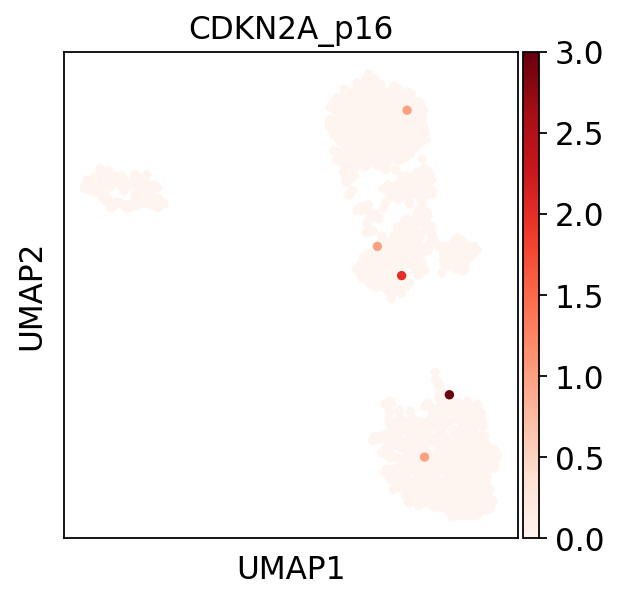

In [47]:
sc.pl.umap(sc1_adata_f, color=['CDKN2A_p16'], color_map='Reds',  use_raw=True, 
           save='Hashimoto_SC1_CDKN2A_p16_RawCounts.pdf')


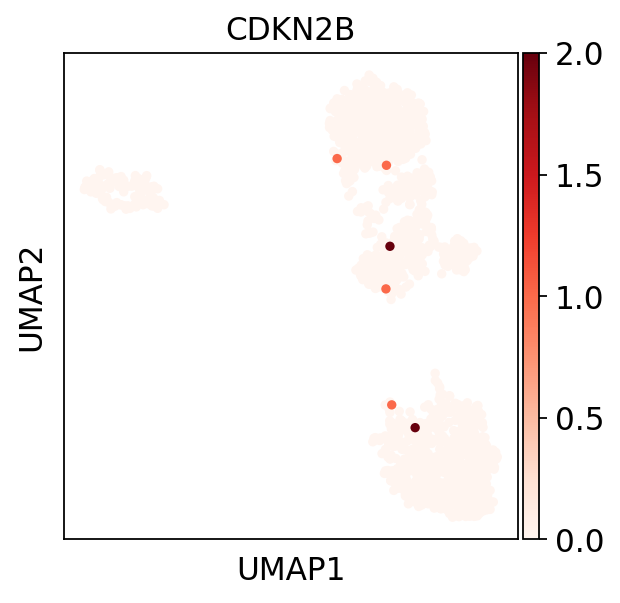

In [48]:
sc.pl.umap(sc1_adata_f, color=['CDKN2B'], color_map='Reds',  use_raw=True, 
           save='Hashimoto_SC1_CDKN2B_p15_RawCounts.pdf')


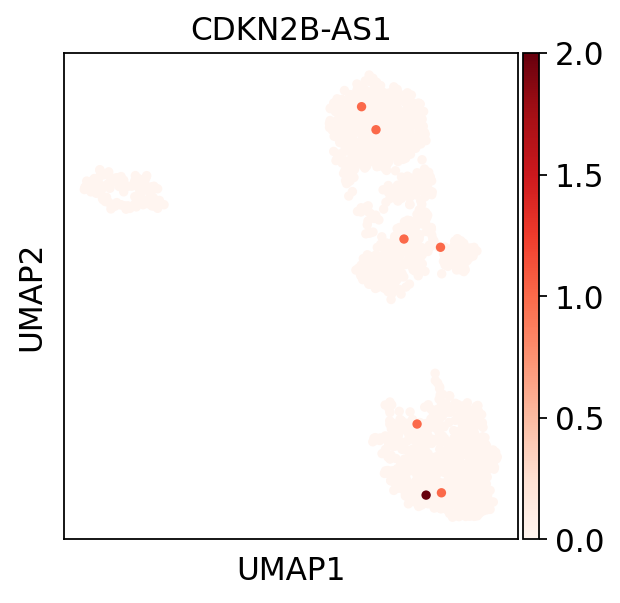

In [49]:
sc.pl.umap(sc1_adata_f, color=['CDKN2B-AS1'], color_map='Reds',  use_raw=True, 
           save='Hashimoto_SC1_CDKN2B-AS1_ANRIL_RawCounts.pdf')


In [50]:
##now similar processing for SC2

In [51]:
sc2 = sc.read_10x_mtx('/seq/epiprod02/etorlait/p16/Published_Data/Centenarian_10x_5p/J-DU000592/FromRiken/05.SC2/')

--> This might be very slow. Consider passing `cache=True`, which enables much faster reading from a cache file.


In [52]:
sc2

AnnData object with n_obs × n_vars = 6956 × 33694
    var: 'gene_ids', 'feature_types'

In [53]:
sc2_list=['SC2_5GEX-' + idx.replace('-1', '') for idx in sc2.obs.index]
sc2_list2=[idx.replace('-1', '') for idx in sc2.obs.index]

In [54]:
len(sc2_list)

6956

In [55]:
sc2_list2

['AAACCTGAGGGTATCG',
 'AAACCTGCAAGGTTTC',
 'AAACCTGCACAACGCC',
 'AAACCTGCATGTCCTC',
 'AAACCTGGTCGCCATG',
 'AAACCTGGTGGTTTCA',
 'AAACCTGGTTGTTTGG',
 'AAACCTGTCACCGGGT',
 'AAACCTGTCGCGCCAA',
 'AAACCTGTCTATCCTA',
 'AAACCTGTCTCTAAGG',
 'AAACGGGAGACTACAA',
 'AAACGGGAGGGTGTGT',
 'AAACGGGAGTAATCCC',
 'AAACGGGCAAGAAGAG',
 'AAACGGGCACGAAATA',
 'AAACGGGCAGGGTATG',
 'AAACGGGCATCGGACC',
 'AAACGGGCATGGATGG',
 'AAACGGGGTAAATGTG',
 'AAACGGGGTAGGCTGA',
 'AAACGGGGTGCAACGA',
 'AAACGGGGTTCCACAA',
 'AAACGGGGTTGGGACA',
 'AAACGGGTCACCATAG',
 'AAACGGGTCCGCGGTA',
 'AAACGGGTCTTATCTG',
 'AAAGATGAGAAACCGC',
 'AAAGATGAGACAAGCC',
 'AAAGATGAGACACTAA',
 'AAAGATGAGAGCCTAG',
 'AAAGATGAGCCATCGC',
 'AAAGATGAGCTAAACA',
 'AAAGATGAGGGTATCG',
 'AAAGATGAGTCACGCC',
 'AAAGATGCAAACGCGA',
 'AAAGATGCAAGGGTCA',
 'AAAGATGCAGCGTCCA',
 'AAAGATGCATCATCCC',
 'AAAGATGGTACAGTTC',
 'AAAGATGGTAGCTCCG',
 'AAAGATGGTCCCGACA',
 'AAAGATGGTCTCAACA',
 'AAAGATGGTTGCGCAC',
 'AAAGATGTCGCCGTGA',
 'AAAGATGTCGCTTAGA',
 'AAAGATGTCTAAGCCA',
 'AAAGCAAAGAC

In [56]:
len(sc2_list2)

6956

In [57]:
sc2_adata = sc.read_10x_mtx('/seq/epiprod02/etorlait/p16/Published_Data/Centenarian_10x_5p/J-DU000592/FromTerra/Mapped_STARsolo_VersionB_newSTsl/SC2_5GEX/Solo.out/Gene/raw/')

--> This might be very slow. Consider passing `cache=True`, which enables much faster reading from a cache file.


In [58]:
sc2_adata

AnnData object with n_obs × n_vars = 737280 × 60670
    var: 'gene_ids', 'feature_types'

In [59]:
sc2_adata_f=sc2_adata[sc2_adata.obs.index.isin(sc2_list2)]

In [60]:
sc2_adata_f

View of AnnData object with n_obs × n_vars = 6956 × 60670
    var: 'gene_ids', 'feature_types'

In [61]:
list(set(sc2_list2) - set(sc2_adata_f.obs.index))

[]

In [62]:
sc2_genes=sc.get.obs_df(sc2_adata_f, keys=["CDKN2A_p14", "CDKN2A_p16", "CDKN2B", "CDKN2B-AS1"])

In [75]:
sc2_genes.CDKN2A_p14.value_counts()

0.0    6748
1.0     196
2.0      12
Name: CDKN2A_p14, dtype: int64

In [76]:
sc2_genes.CDKN2A_p16.value_counts()

0.0    6944
1.0      10
2.0       2
Name: CDKN2A_p16, dtype: int64

In [77]:
sc2_genes.CDKN2B.value_counts()

0.0    6952
1.0       4
Name: CDKN2B, dtype: int64

In [78]:
sc2_genes['CDKN2B-AS1'].value_counts()

0.0    6940
1.0      16
Name: CDKN2B-AS1, dtype: int64

normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)
computing PCA
    on highly variable genes
    with n_comps=50
    finished (0:00:00)


/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  cax = scatter(


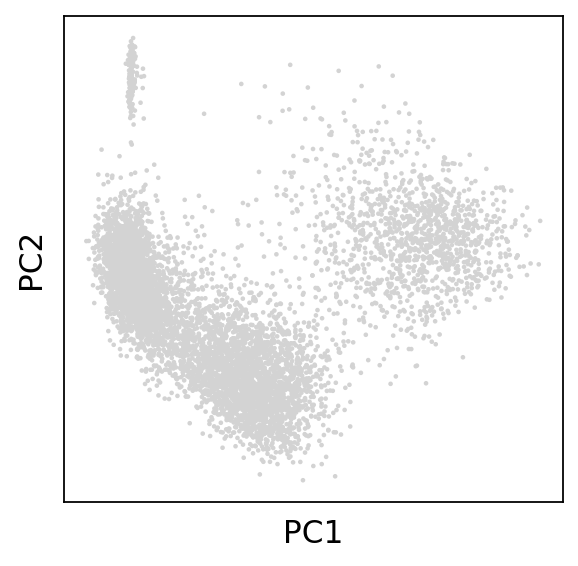

computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:00)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:15)


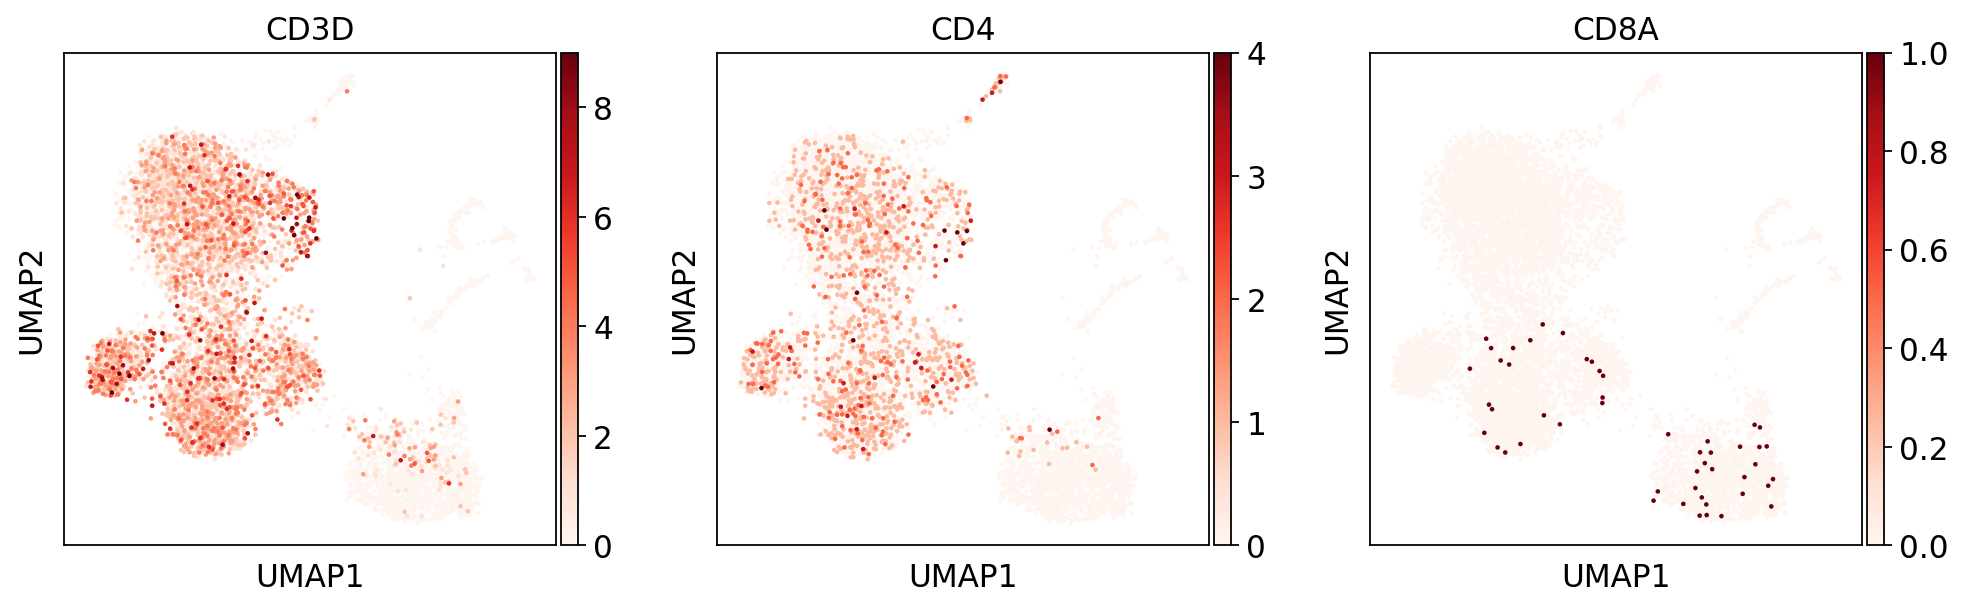

In [63]:
sc2_adata_f.raw = sc2_adata_f.copy()

sc.pp.normalize_total(sc2_adata_f, target_sum=1e4)
sc.pp.log1p(sc2_adata_f)
sc.pp.highly_variable_genes(sc2_adata_f)

sc.tl.pca(sc2_adata_f, svd_solver='arpack')
sc.pl.pca(sc2_adata_f)
sc.pp.neighbors(sc2_adata_f)
sc.tl.umap(sc2_adata_f)
sc.pl.umap(sc2_adata_f, color=['CD3D', 'CD4', 'CD8A'], color_map='Reds', vmax='p99.9')


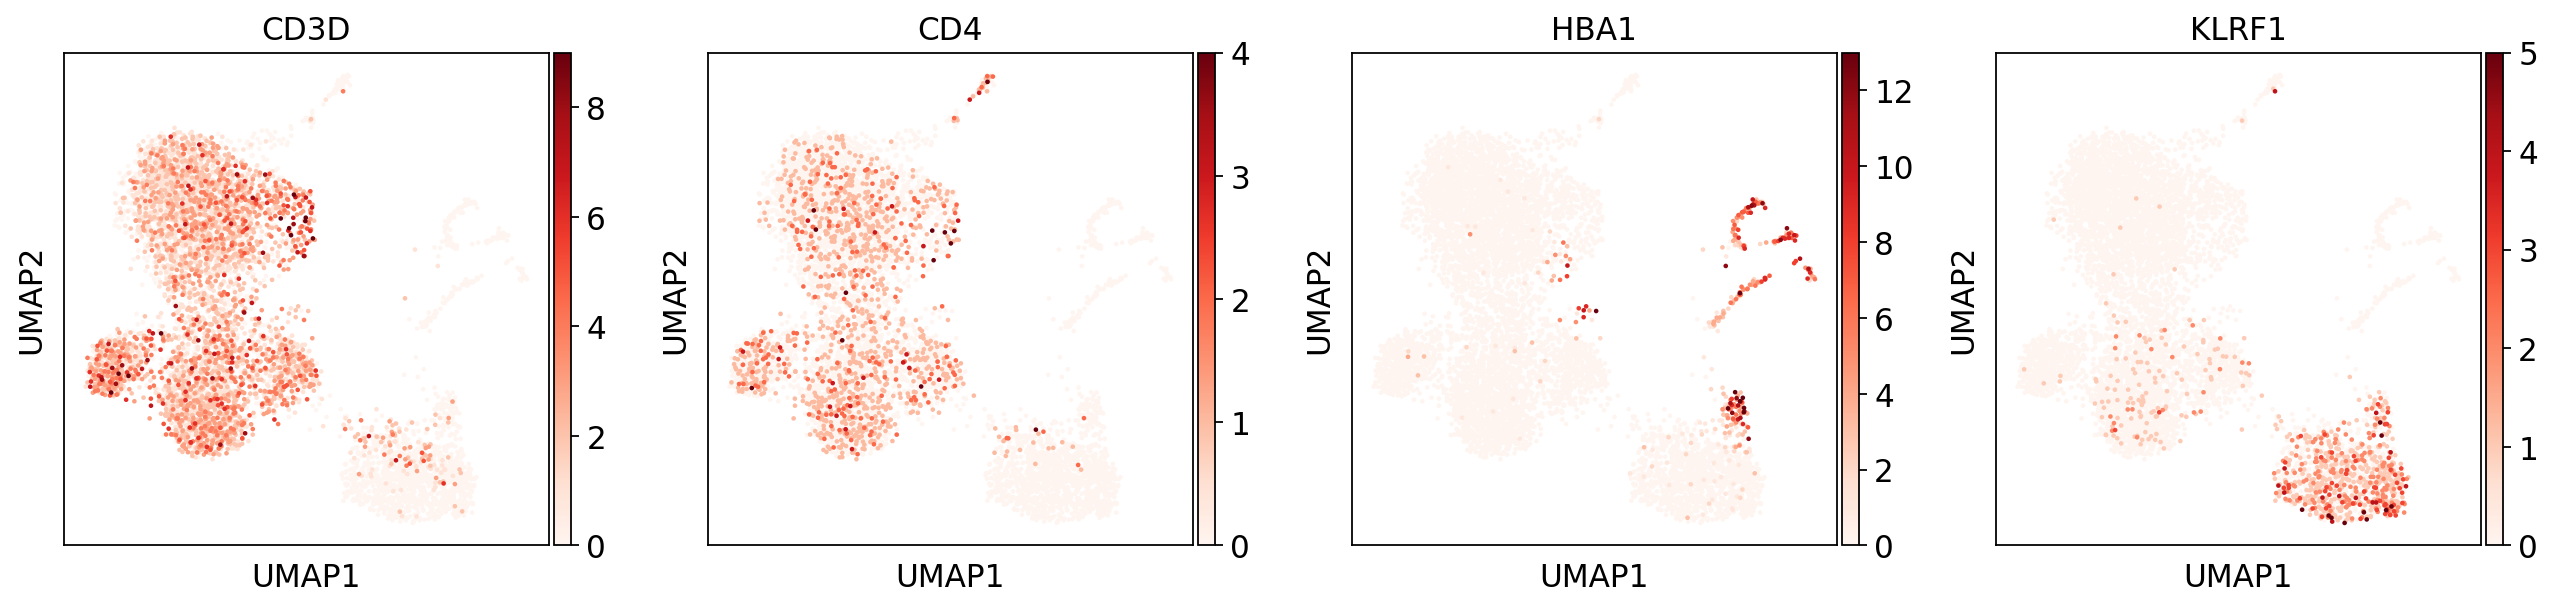

In [64]:
sc.pl.umap(sc2_adata_f, color=['CD3D', 'CD4', 'HBA1', 'KLRF1'], color_map='Reds', vmax='p99.9')


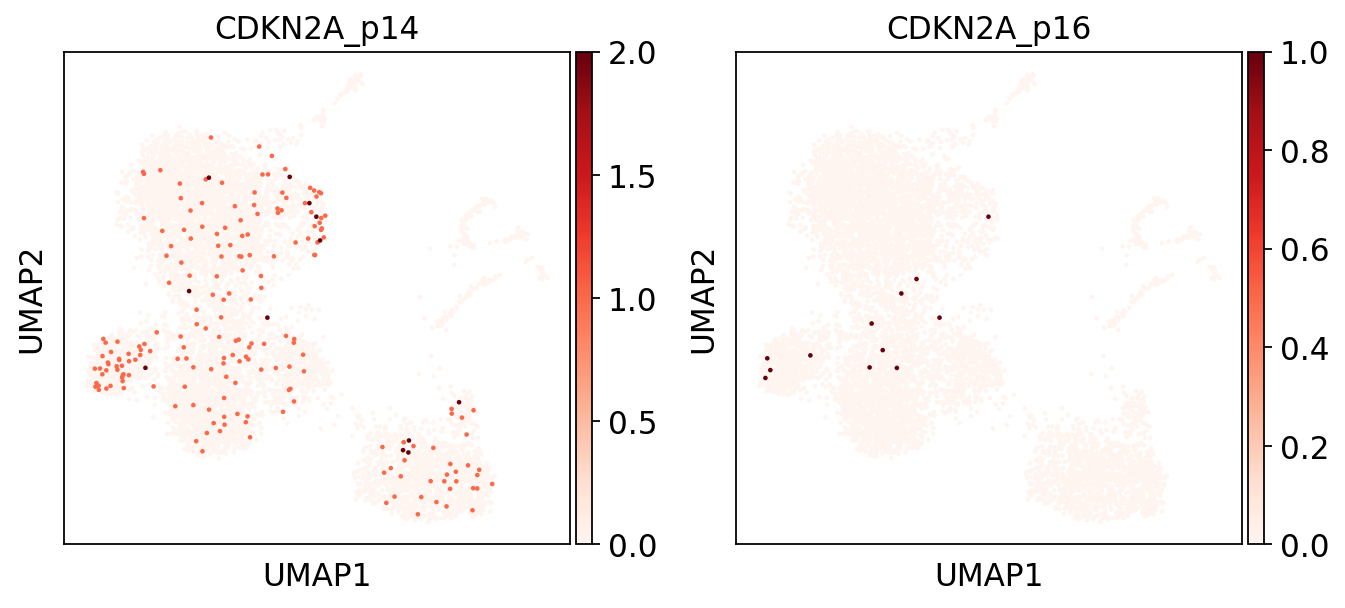

In [65]:
sc.pl.umap(sc2_adata_f, color=['CDKN2A_p14', 'CDKN2A_p16'], color_map='Reds', vmax='p99.9')


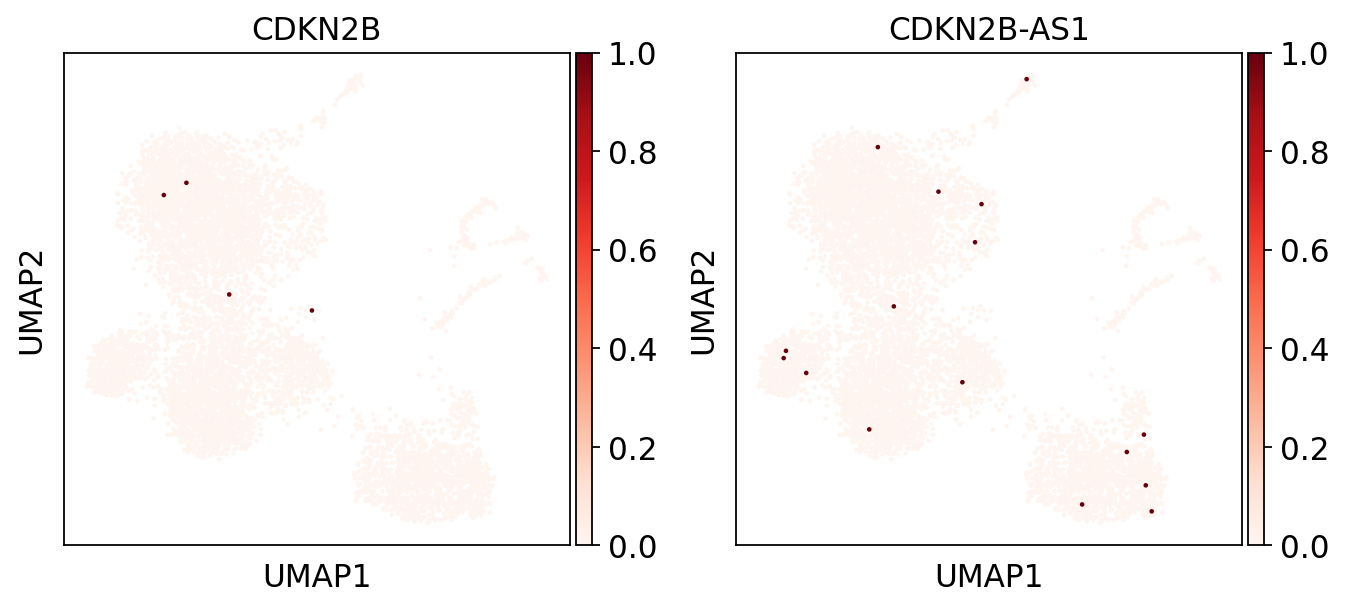

In [66]:
sc.pl.umap(sc2_adata_f, color=['CDKN2B', 'CDKN2B-AS1'], color_map='Reds')


In [67]:
sc.tl.leiden(sc2_adata_f,
    resolution=0.05,
    random_state=0,
    n_iterations=2,
    directed=False,
)

running Leiden clustering
    finished: found 4 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)


/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


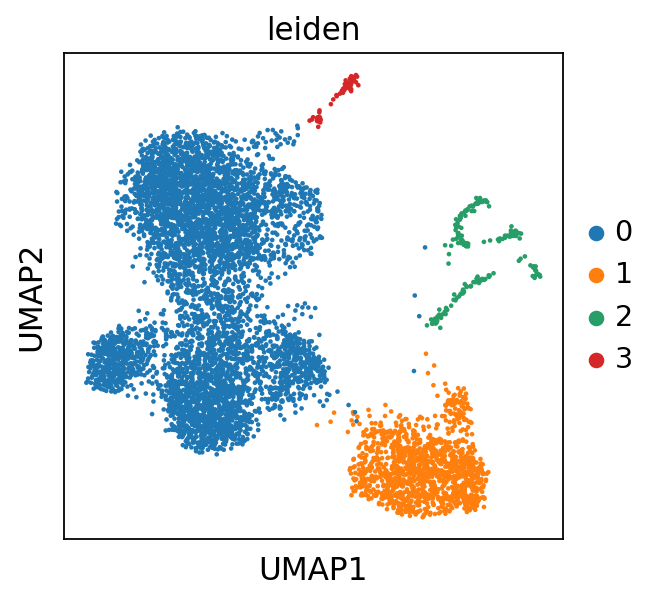

In [68]:
sc.pl.umap(sc2_adata_f, color=['leiden'])


In [69]:
sc2_adata_f.obs['cellType'] = 'T_cell'  
sc2_adata_f.obs.loc[sc2_adata_f.obs['leiden'] == '1', 'cellType'] = 'NK_cell'
sc2_adata_f.obs.loc[sc2_adata_f.obs['leiden'] == '2', 'cellType'] = 'Ery_cell'
sc2_adata_f.obs.loc[sc2_adata_f.obs['leiden'] == '3', 'cellType'] = 'Other'

In [70]:
sc2_adata_f.obs['leiden'].value_counts()

0    5473
1    1249
2     168
3      66
Name: leiden, dtype: int64

In [71]:
sc2_adata_f.obs['cellType'].value_counts()


T_cell      5473
NK_cell     1249
Ery_cell     168
Other         66
Name: cellType, dtype: int64

/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


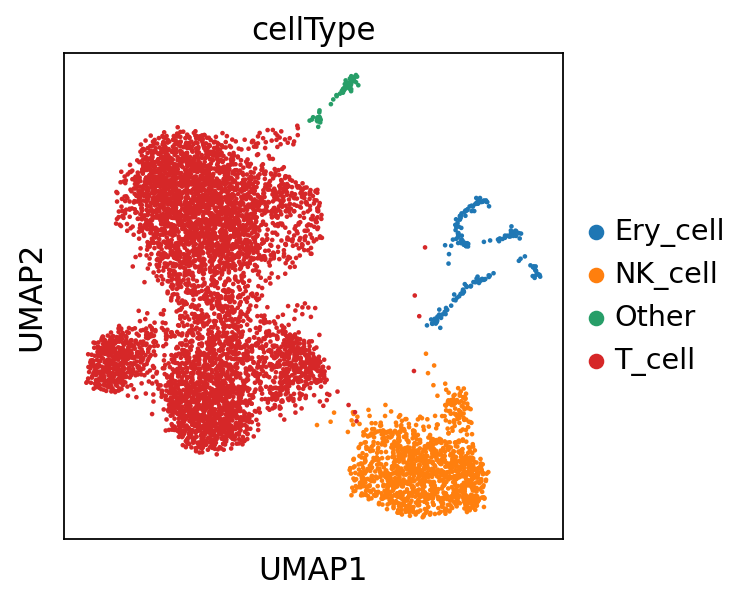

In [73]:
sc.pl.umap(sc2_adata_f, color=['cellType'])


/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


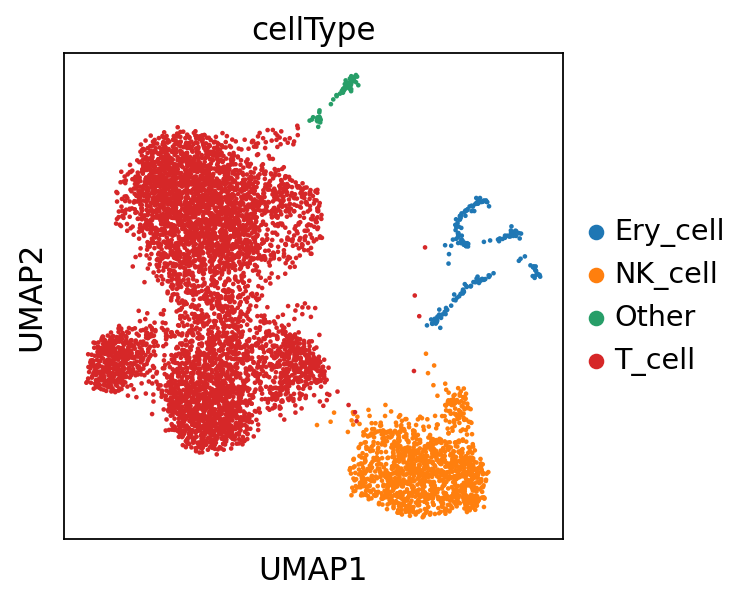

In [80]:
sc.pl.umap(sc2_adata_f, color=['cellType'], save='Hashimoto_SC2_Celltypes.pdf')


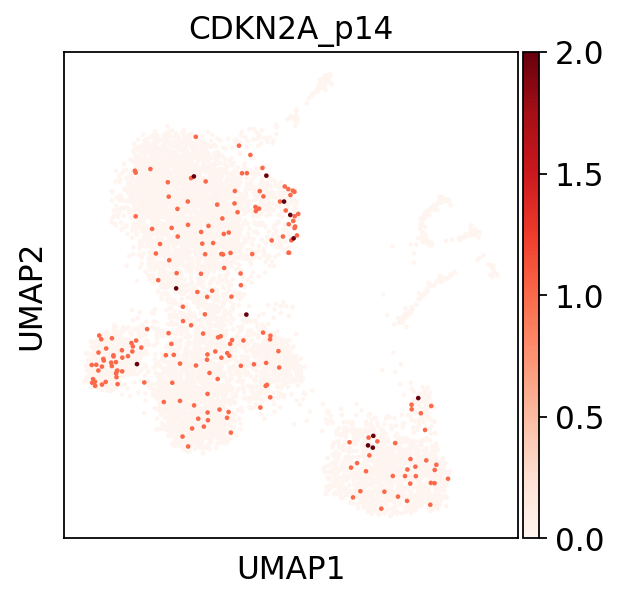

In [81]:
sc.pl.umap(sc2_adata_f, color=['CDKN2A_p14'], color_map='Reds',  use_raw=True, 
           save='Hashimoto_SC2_CDKN2A_p14_RawCounts.pdf')


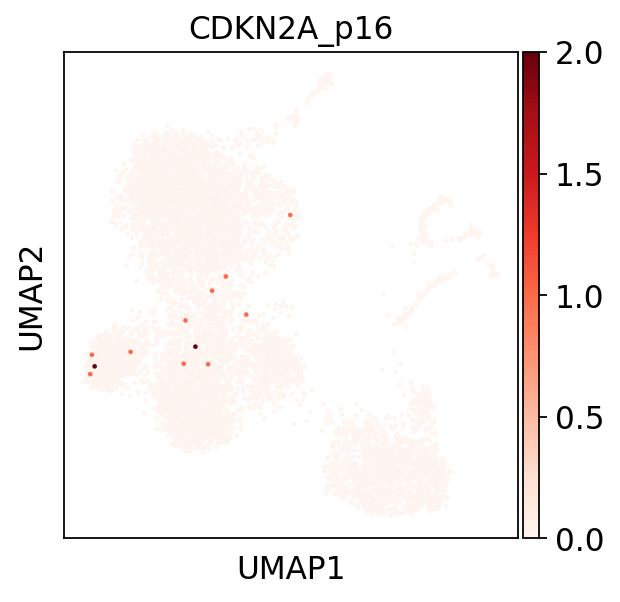

In [82]:
sc.pl.umap(sc2_adata_f, color=['CDKN2A_p16'], color_map='Reds',  use_raw=True, 
           save='Hashimoto_SC2_CDKN2A_p16_RawCounts.pdf')


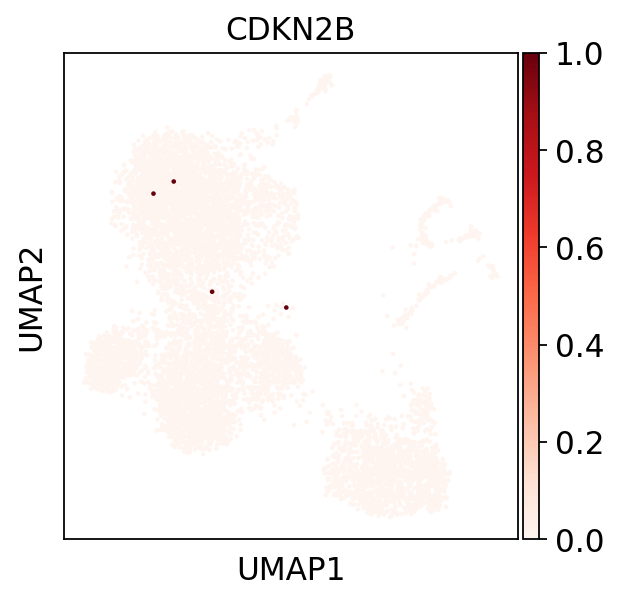

In [83]:
sc.pl.umap(sc2_adata_f, color=['CDKN2B'], color_map='Reds',  use_raw=True, 
           save='Hashimoto_SC2_CDKN2B_p15_RawCounts.pdf')


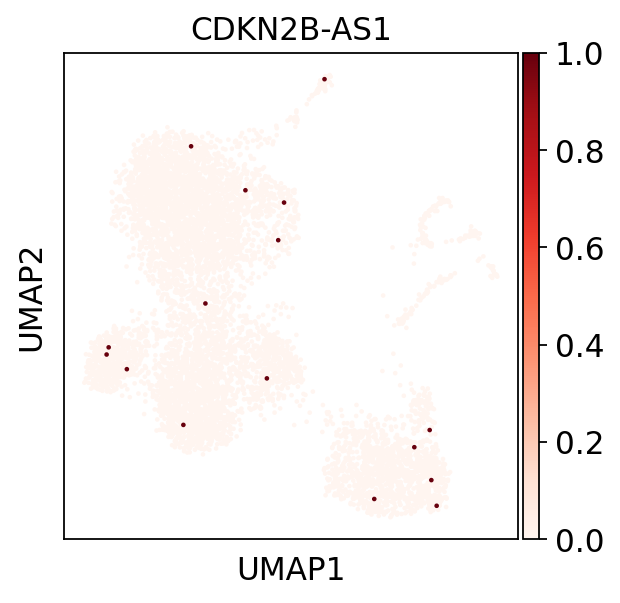

In [84]:
sc.pl.umap(sc2_adata_f, color=['CDKN2B-AS1'], color_map='Reds',  use_raw=True, 
           save='Hashimoto_SC2_CDKN2B-AS1_ANRIL_RawCounts.pdf')


In [74]:
sc2_data= sc.get.obs_df(sc2_adata_f,
        keys=["cellType",'CDKN2A_p14', 'CDKN2A_p16', 'CDKN2B', 'CDKN2B-AS1'], use_raw=True    )

In [79]:
sc2_data.CDKN2A_p16.value_counts()

0.0    6944
1.0      10
2.0       2
Name: CDKN2A_p16, dtype: int64

In [85]:
sc2_data.to_csv('/seq/epiprod02/etorlait/p16/Published_Data/Centenarian_10x_5p/J-DU000592/FromTerra/Mapped_STARsolo_VersionB_newSTsl/SC2_idsFromRiken_celltype_9p21genes.tsv', sep='\t')

In [ ]:
###plotting

In [86]:
total_counts_sc1 = sc1_data.groupby('cellType').size()
total_counts_sc1

cellType
Ery_cell     103
T_cell      1583
dtype: int64

In [87]:
##p14

# Count cells where p14 > 0 per cellType
above_threshold_counts_p14_sc1 = sc1_data[sc1_data['CDKN2A_p14'] > 0].groupby('cellType').size()

# Calculate percentage of p14 expressors per cellType
percentage_above_threshold_p14_sc1 = (above_threshold_counts_p14_sc1 / total_counts_sc1) * 100


In [97]:
percentage_above_threshold_p14_sc1

cellType
Ery_cell         NaN
T_cell      6.380291
dtype: float64

In [88]:
##p16

# Count cells where p16 > 0 per cellType
above_threshold_counts_p16_sc1 = sc1_data[sc1_data['CDKN2A_p16'] > 0].groupby('cellType').size()

# Calculate percentage of p16 expressors per cellType
percentage_above_threshold_p16_sc1 = (above_threshold_counts_p16_sc1 / total_counts_sc1) * 100


In [98]:
percentage_above_threshold_p16_sc1

cellType
Ery_cell         NaN
T_cell      0.315856
dtype: float64

In [89]:
##p15

# Count cells where p15 > 0 per cellType
above_threshold_counts_p15_sc1 = sc1_data[sc1_data['CDKN2B'] > 0].groupby('cellType').size()

# Calculate percentage of p15 expressors per cellType
percentage_above_threshold_p15_sc1 = (above_threshold_counts_p15_sc1 / total_counts_sc1) * 100


In [90]:
##ANRIL

# Count cells where ANRIL > 0 per cellType
above_threshold_counts_ANRIL_sc1 = sc1_data[sc1_data['CDKN2B-AS1'] > 0].groupby('cellType').size()

# Calculate percentage of ANRIL expressors per cellType
percentage_above_threshold_ANRIL_sc1 = (above_threshold_counts_ANRIL_sc1 / total_counts_sc1) * 100


In [91]:
## Get numbers for sample #2 i.e. sc2

In [92]:
total_counts_sc2 = sc2_data.groupby('cellType').size()
total_counts_sc2

cellType
Ery_cell     168
NK_cell     1249
Other         66
T_cell      5473
dtype: int64

In [93]:
##p14

# Count cells where p14 > 0 per cellType
above_threshold_counts_p14_sc2 = sc2_data[sc2_data['CDKN2A_p14'] > 0].groupby('cellType').size()

# Calculate percentage of p14 expressors per cellType
percentage_above_threshold_p14_sc2 = (above_threshold_counts_p14_sc2 / total_counts_sc2) * 100


In [94]:
##p16

# Count cells where p16 > 0 per cellType
above_threshold_counts_p16_sc2 = sc2_data[sc2_data['CDKN2A_p16'] > 0].groupby('cellType').size()

# Calculate percentage of p16 expressors per cellType
percentage_above_threshold_p16_sc2 = (above_threshold_counts_p16_sc2 / total_counts_sc2) * 100


In [95]:
##p15

# Count cells where p15 > 0 per cellType
above_threshold_counts_p15_sc2 = sc2_data[sc2_data['CDKN2B'] > 0].groupby('cellType').size()

# Calculate percentage of p15 expressors per cellType
percentage_above_threshold_p15_sc2 = (above_threshold_counts_p15_sc2 / total_counts_sc2) * 100


In [96]:
##ANRIL

# Count cells where ANRIL > 0 per cellType
above_threshold_counts_ANRIL_sc2 = sc2_data[sc2_data['CDKN2B-AS1'] > 0].groupby('cellType').size()

# Calculate percentage of ANRIL expressors per cellType
percentage_above_threshold_ANRIL_sc2 = (above_threshold_counts_ANRIL_sc2 / total_counts_sc2) * 100


In [ ]:
#Combine tables and plot

In [119]:
from scipy.stats import sem


In [111]:
percentage_above_threshold_p14_sc1

cellType
Ery_cell         NaN
T_cell      6.380291
dtype: float64

In [113]:
percentage_above_threshold_p14_sc2

cellType
Ery_cell    0.000000
NK_cell     2.962370
Other       0.000000
T_cell      3.124429
dtype: float64

In [115]:
def compute_expression_fraction(df, genes_to_plot):
    fractions = []
    for cell_type, group in df.groupby('cellType'):
        total = len(group)
        for gene in genes_to_plot:
            expressed = (group[gene] > 0).sum()
            percent = 100 * expressed / total
            fractions.append({'cellType': cell_type, 'gene': gene, 'percent': percent})
    return pd.DataFrame(fractions)

In [117]:
genes_to_plot = ['CDKN2A_p14', 'CDKN2A_p16', 'CDKN2B', 'CDKN2B-AS1']

frac1 = compute_expression_fraction(sc1_data, genes_to_plot)
frac1['sample'] = 'SC1'

frac2 = compute_expression_fraction(sc2_data, genes_to_plot)
frac2['sample'] = 'SC2'

combined = pd.concat([frac1, frac2])
combined

,cellType,gene,percent,sample
0,Ery_cell,CDKN2A_p14,0.000000,SC1
1,Ery_cell,CDKN2A_p16,0.000000,SC1
2,Ery_cell,CDKN2B,0.000000,SC1
3,Ery_cell,CDKN2B-AS1,0.000000,SC1
4,T_cell,CDKN2A_p14,6.380291,SC1
5,T_cell,CDKN2A_p16,0.315856,SC1
6,T_cell,CDKN2B,0.379027,SC1
7,T_cell,CDKN2B-AS1,0.442198,SC1
0,Ery_cell,CDKN2A_p14,0.000000,SC2
1,Ery_cell,CDKN2A_p16,0.000000,SC2


In [122]:
table_to_plot = (
    combined.groupby(['cellType', 'gene'])['percent']
    .agg(['mean', sem]).reset_index()
)

/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/site-packages/numpy/core/_methods.py:265: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/site-packages/numpy/core/_methods.py:257: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


In [123]:
table_to_plot

,cellType,gene,mean,sem
0,Ery_cell,CDKN2A_p14,0.000000,0.000000
1,Ery_cell,CDKN2A_p16,0.000000,0.000000
2,Ery_cell,CDKN2B,0.000000,0.000000
3,Ery_cell,CDKN2B-AS1,0.000000,0.000000
4,NK_cell,CDKN2A_p14,2.962370,NaN
5,NK_cell,CDKN2A_p16,0.000000,NaN
6,NK_cell,CDKN2B,0.000000,NaN
7,NK_cell,CDKN2B-AS1,0.400320,NaN
8,Other,CDKN2A_p14,0.000000,NaN
9,Other,CDKN2A_p16,0.000000,NaN


/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/site-packages/matplotlib/axes/_axes.py:1180: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
/home/unix/etorlait/miniconda3/envs/scanpy/lib/python3.9/site-packages/matplotlib/axes/_axes.py:1181: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])


<Figure size 1000x600 with 0 Axes>

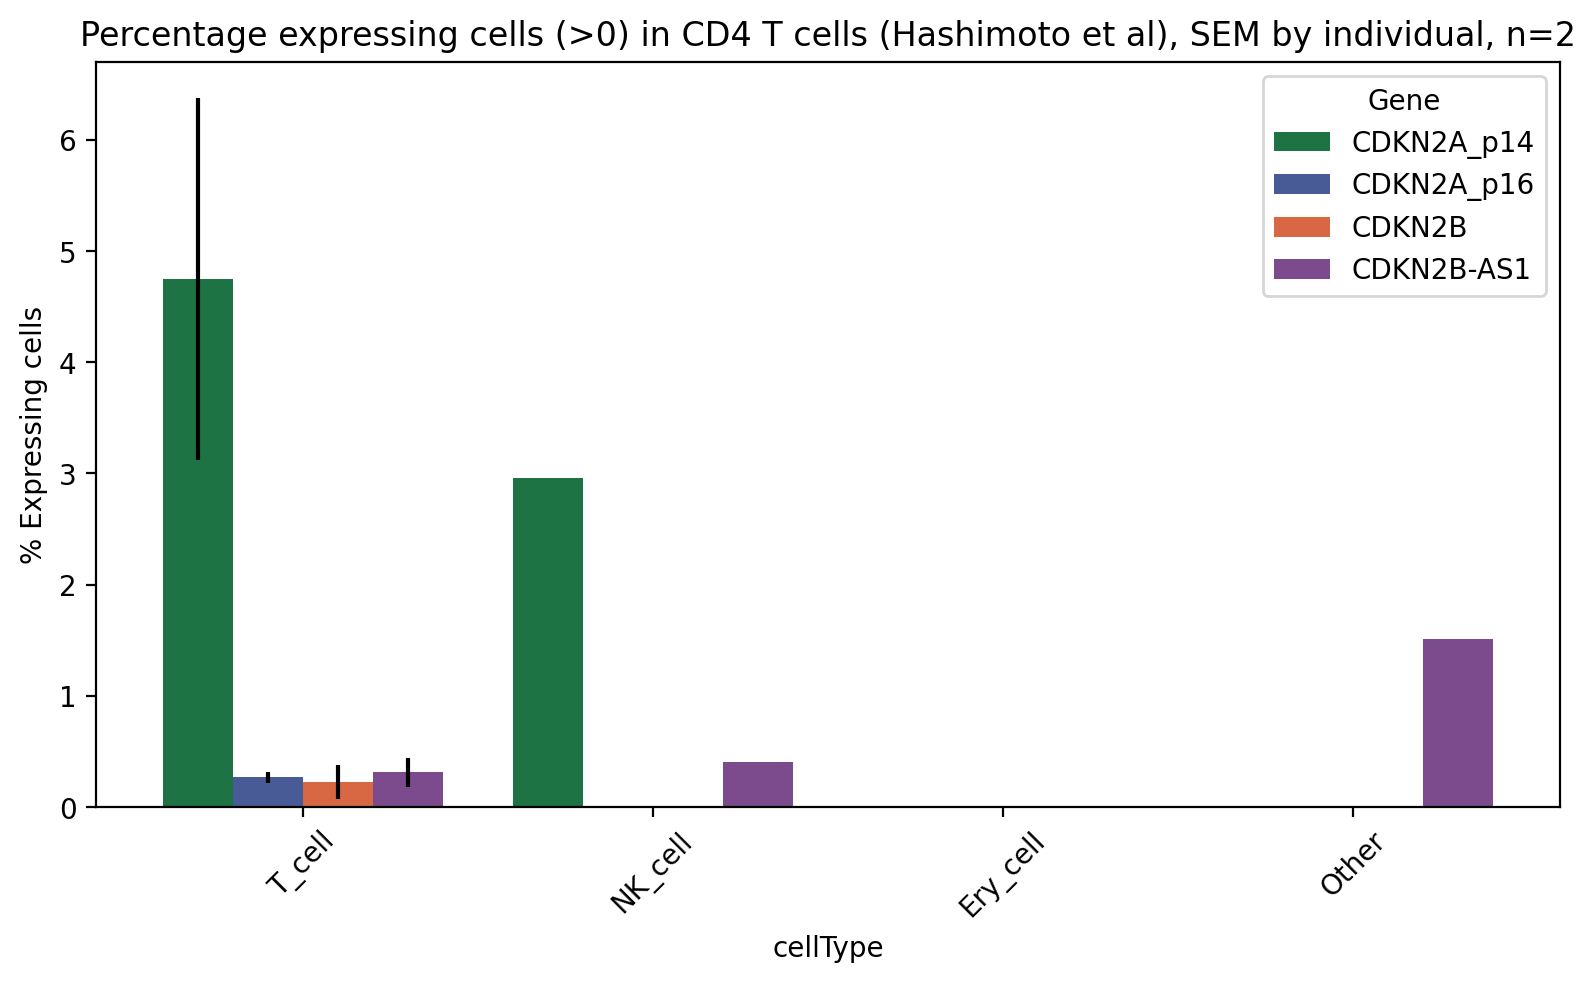

In [128]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.style.use('default')
# Set consistent plotting order
cell_type_order = ['T_cell', 'NK_cell', 'Ery_cell', 'Other']
gene_order = table_to_plot['gene'].unique()

# Plot without built-in error bars
plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=table_to_plot,
    x='cellType',
    y='mean',
    hue='gene',
    hue_order=gene_order,
    order=cell_type_order,
    palette=['#0F8141','#3C54A4', '#F15A2B', '#804098'],
    errorbar=None
)

# Get the offsets of the grouped bars
n_genes = len(gene_order)
bar_width = 0.8 / n_genes  # seaborn default bar grouping spacing

# Add error bars manually
for i, (cell_type) in enumerate(cell_type_order):
    for j, gene in enumerate(gene_order):
        # Get the row matching this bar
        row = table_to_plot[(table_to_plot['cellType'] == cell_type) & (table_to_plot['gene'] == gene)]
        if row.empty:
            continue
        mean_val = row['mean'].values[0]
        sem_val = row['sem'].values[0]

        # Calculate bar center
        bar_x = i - 0.4 + bar_width/2 + j * bar_width  # align with bar center
        ax.errorbar(x=bar_x, y=mean_val, yerr=sem_val, fmt='none', color='black')

# Final plot formatting
plt.ylabel('% Expressing cells')
plt.title('Percentage expressing cells (>0) in CD4 T cells (Hashimoto et al), SEM by individual, n=2')
plt.xticks(ticks=range(len(cell_type_order)), labels=cell_type_order)
plt.xticks(rotation=45)

plt.legend(title='Gene')
plt.tight_layout()

plt.savefig("figures/Hashimoto_PercentExpressing_GroupedBarplot_Groups_AsInPaper_T_NKCellsSep.pdf", format='pdf', dpi=300)
